/var/folders/rc/j7msd26n49b866wt4d672wlr0000gn/T/ipykernel_56799/4152877441.py:146: RuntimeWarning: invalid value encountered in divide
  a_star         = z_sum / np.linalg.norm(z_sum)      # best fixed action


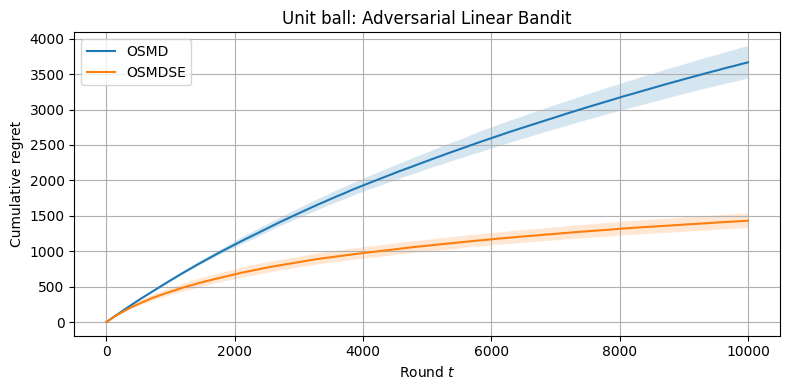

[    1  1000  2000  3000  4000  5000  6000  7000  8000  9000 10000]
[1.00000e+00 5.88180e+02 1.09276e+03 1.53559e+03 1.92783e+03 2.27330e+03
 2.59583e+03 2.89180e+03 3.16900e+03 3.42709e+03 3.66609e+03]
[1.00000e+00 4.28620e+02 6.72290e+02 8.45960e+02 9.73680e+02 1.07696e+03
 1.16678e+03 1.24452e+03 1.31591e+03 1.37449e+03 1.42991e+03]


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------- helpers -----------------------------

def sample_sparse_ball(d, s, support, rng):
    v = np.zeros(d)
    direction = rng.normal(size=s)
    norm_dir = np.linalg.norm(direction)
    if norm_dir == 0.0:
        direction[0] = 1.0
        norm_dir = 1.0
    direction = direction / norm_dir
    radius = rng.random() ** (1.0 / s)
    for idx in range(s):
        v[support[idx]] = radius * direction[idx]
    return v


def grad_F(x):
    """
    ∇F(x) = x / (1 - ‖x‖).
    Assumes ‖x‖ < 1, which is maintained by the algorithm.
    """
    norm_x = np.linalg.norm(x)
    return x / (1.0 - norm_x)


def grad_F_inv(u):
    """
    Inverse map ∇F* : u → u / (1 + ‖u‖).
    """
    norm_u = np.linalg.norm(u)
    return u / (1.0 + norm_u)

def project_l2_ball(x, r):
    if np.linalg.norm(x) > r:
        scale = r / np.linalg.norm(x)
    else:
        scale  = 1
    return x * scale

def generate_loss_sequence_bias(d, s, T, rng, mean_radius=0.8):
    """
    Returns
    -------
    losses : ndarray, shape (T, d)   (each row is s‑sparse, ‖·‖₂ ≤ 1)
    
    If you also want the mean vector μ and the support, call
        losses, mu, support = generate_loss_sequence_bias(..., return_details=True)
    """
    # ---------- support ----------
    support = rng.choice(d, size=s, replace=False)

    # ---------- mean μ on that support ----------
    direction = rng.normal(size=s)
    direction /= np.linalg.norm(direction)
    mu = np.zeros(d)
    mu[support] = mean_radius * direction        # ‖μ‖₂ = mean_radius < 1

    # ---------- build loss matrix ----------
    losses = np.zeros((T, d))
    for t in range(T):
        z = np.zeros(d)
        for idx in support:
            p_plus = 0.5 * (1.0 + mu[idx])       # Rademacher(μ_i)
            z[idx] = 1.0 if rng.random() < p_plus else -1.0
        norm_z = np.linalg.norm(z)
        if norm_z > 1.0:                         # project to unit ball
            z /= norm_z
        losses[t, :] = z                         # 1‑D row stored as (d,)

    return losses          # <‑‑ ONLY the (T,d) array



# ----------------------------- core algorithm -----------------------------

# ------------------------- core algorithm (revised) ----------------------
def run_osmd_selective(d, s, T, H, losses, seed):
    """
    H = 1  → OSMD       (no selective exploration)
    H = d  → OSMDSE     (selective exploration weight)
    losses : (T × d) ndarray supplied by the caller
    """
    rng = np.random.default_rng(seed)

    gamma = 1.0 / np.sqrt(T)
    #gamma = 0.05
    eta   = 1.0 / (4.0 * np.sqrt((d if H == 1 else s) * T))

    loss_hist   = np.zeros(T)
    z_norm_hist = np.zeros(T)

    a_t = np.zeros(d)
    u_t = grad_F(a_t)

    w_t = np.ones(d)
    rho_t = w_t / w_t.sum()

    z_sum = np.zeros(d)

    for t in range(T):
        #print(losses[t])
        #print(z_sum)
        z_t = losses[t,:]          # <‑‑ pre‑generated loss vector
        z_sum += z_t

        # --- play arm ---
        xi = 1 if rng.random() < np.linalg.norm(a_t) else 0
        if xi == 1:                         # exploitation
            norm_a = np.linalg.norm(a_t)
            a_tilde = a_t / norm_a if norm_a > 0 else np.zeros(d)
            It = -1
        else:                              # exploration
            It = rng.choice(d, p = rho_t)
            a_tilde = np.zeros(d)
            a_tilde[It] = 1.0 if rng.random() < 0.5 else -1.0

        # --- observe loss & build estimator ---
        l_t   = float(np.dot(a_tilde, z_t))
        denom = 1.0 - np.linalg.norm(a_t)
        if denom < 1e-12:
            denom = 1e-12
        coeff      = (1 - xi) * l_t / (rho_t[It] * denom) if xi == 0 else 0.0
        ell_hat    = coeff * a_tilde            # full d‑vector

        # --- mirror step (dual then primal) ---
        u_t = u_t - eta * ell_hat
        a_t = grad_F_inv(u_t)
        a_t = project_l2_ball(a_t, 1 - gamma)

       # if H==1:
        #    print("OMSD action:", a_t)
       ## else:
        #    print("OMSDSE action:", a_t)

        # --- update exploration weights if OSMDSE ---
        if H > 1 and xi == 0 and abs(z_t[It]) > 1e-12:
            w_t[It] = H
            rho_t   = w_t / w_t.sum()
        ##print("w_t", w_t)
        
        # --- bookkeeping ---
        loss_hist[t]   = l_t
        a_star         = z_sum / np.linalg.norm(z_sum)      # best fixed action
        z_norm_hist[t] = -np.dot(a_star, z_sum)

    cumulative_loss = np.cumsum(loss_hist)
    regret          = cumulative_loss - z_norm_hist
    return regret


# ----------------------------- multi‑run experiment -----------------------------

def compare_with_std(d, s, T, runs, seed_base=0):
    reg_osmd   = np.zeros((runs, T))
    reg_osmdse = np.zeros((runs, T))

    for r in range(runs):
        rng_loss = np.random.default_rng(seed_base + r)     # one RNG for losses
        losses   = generate_loss_sequence_bias(d, s, T, rng_loss, mean_radius=0.9)
        #print(losses[1])
        # same losses fed to both algorithms (fair comparison)
        reg_osmd[r]   = run_osmd_selective(d, s, T, H=1,   losses=losses, seed = seed_base+1000+r)
        reg_osmdse[r] = run_osmd_selective(d, s, T, H=d,   losses=losses, seed = seed_base+1000+r)

    # expectation and ± 1 std
    mean_osmd,  std_osmd  = reg_osmd.mean(0),  reg_osmd.std(0)
    mean_se,    std_se    = reg_osmdse.mean(0), reg_osmdse.std(0)

    x = np.arange(1, T+1)
    plt.figure(figsize=(8,4))

    plt.plot(x, mean_osmd,  label='OSMD')
    plt.fill_between(x, mean_osmd-std_osmd,  mean_osmd+std_osmd,  alpha=0.18, linewidth=0)
    plt.plot(x, mean_se,    label='OSMDSE')
    plt.fill_between(x, mean_se-std_se,     mean_se+std_se,     alpha=0.18, linewidth=0)

    plt.xlabel('Round $t$')
    plt.ylabel('Cumulative regret')
    plt.title(f'Unit ball: Adversarial Linear Bandit')
    plt.grid(True);  plt.legend();  plt.tight_layout();      plt.savefig('UnitBall.png', dpi=300)
    plt.show()

    index_plot = np.linspace(0, T-1, num=11, dtype = int)
    print(index_plot+1)
    print(np.round(mean_osmd[index_plot],2))
    print(np.round(mean_se[index_plot],2))
# ----------------------------- demo -----------------------------
d, s, T, runs = 80, 2 , 10000, 20
compare_with_std(d, s, T, runs)

